# Data Exploration (EDA)
This notebook explores and validates the customer support evaluation dataset before training.

The goal of this notebook is to understand the structure and quality of the collected data and prepare it for later stages of the project.

In this notebook we will:

- Load and inspect the dataset.
- Verify that all required fields exist.
- Explore the overall structure and content.
- Check for missing or invalid values.
- Analyze score distribution.
- Prepare the dataset for train, validation, and test splitting.

This step is important because model quality depends heavily on dataset quality and consistency.

## 1. Import Libraries
In this section, we import the Python libraries that will be used throughout the notebook.


In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

## 2. Load Dataset
we load the dataset from the JSONL file into a pandas DataFrame.

The dataset is stored in JSON Lines (JSONL) format, where each line represents one complete evaluation example.

Each example contains the six required fields of the project:

- task
- reference
- submission
- rubric
- score
- rationale

After loading the data, we convert it into a tabular structure to make inspection and analysis easier in later steps.

We also verify that the dataset file exists before reading it to avoid path-related errors.

In [2]:
dataset_path = Path("../data/dataset.jsonl")

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

records = []

with open(dataset_path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

print(f"Dataset loaded successfully.")
print(f"Number of samples: {len(df)}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully.
Number of samples: 100
Number of columns: 6


## 3. Inspect Dataset Structure
In this section, we inspect the structure and contents of the loaded dataset.

The goal is to verify that the dataset follows the expected project format and that all examples were loaded correctly.

We will:

- Display the first few samples.
- Inspect column names.
- Confirm data types.
- Understand how information is stored.

This inspection step helps detect formatting issues early before training and evaluation.

In [3]:
display(df.head(2))

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

,task,reference,submission,rubric,score,rationale
0,Customer complains that their order has not arrived after the expected delivery date.,We sincerely apologize for the delay. Your order is currently on its way and will arrive within 2 to 3 business days. We understand your frustrati...,Thank you for reaching out. We are truly sorry for the delay and completely understand how frustrating this must be. Your order is on its way and ...,"{'1': 'Shows understanding and apology', '2': 'Provides correct and relevant information', '3': 'Provides clear solution or next step', '4': 'Uses...",4,"The reply is empathetic, accurate, and professional. It apologizes sincerely, gives a specific timeline, and offers further assistance, covering a..."
1,Customer complains that their order has not arrived after the expected delivery date.,We sincerely apologize for the delay. Your order is currently on its way and will arrive within 2 to 3 business days. We understand your frustrati...,We are sorry for the delay. Your order is on its way and should arrive within 2 to 3 business days. We appreciate your patience.,"{'1': 'Shows understanding and apology', '2': 'Provides correct and relevant information', '3': 'Provides clear solution or next step', '4': 'Uses...",3,"The reply is polite and provides the correct timeline, but it lacks any acknowledgment of the customer's frustration and does not offer further as..."



Column Names:
['task', 'reference', 'submission', 'rubric', 'score', 'rationale']

Data Types:
task             str
reference        str
submission       str
rubric        object
score          int64
rationale        str
dtype: object


## 4. Verify Dataset Integrity and Required Fields

Before training any model, it is important to confirm that all samples satisfy the required project format.

We will verify:

- No missing values exist.
- All required columns are present.
- Scores follow the expected discrete scale.
- Each rubric contains the expected evaluation criteria.

This step ensures that the dataset is complete, consistent, and ready for model training.

In [4]:
required_columns = [
    "task",
    "reference",
    "submission",
    "rubric",
    "score",
    "rationale"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing Columns:")
print(missing_columns if missing_columns else "None")

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nScore Values:")
print(sorted(df["score"].unique()))

print("\nRubric Example:")
print(df["rubric"].iloc[0])

Missing Columns:
None

Missing Values Per Column:
task          0
reference     0
submission    0
rubric        0
score         0
rationale     0
dtype: int64

Score Values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Rubric Example:
{'1': 'Shows understanding and apology', '2': 'Provides correct and relevant information', '3': 'Provides clear solution or next step', '4': 'Uses polite and professional tone'}


## 5. Analyze Score Distribution
Since the model will learn to predict scores from customer support replies, it is important to verify that all score categories are reasonably represented.

A balanced distribution helps reduce prediction bias and allows the model to learn examples from all quality levels.

We will:

- Count the number of samples for each score.
- Calculate score percentages.
- Visualize the distribution using a bar chart.

This analysis helps determine whether additional data collection is needed before training.

,Count,Percentage (%)
score,,
0,20,20.0
1,20,20.0
2,20,20.0
3,20,20.0
4,20,20.0


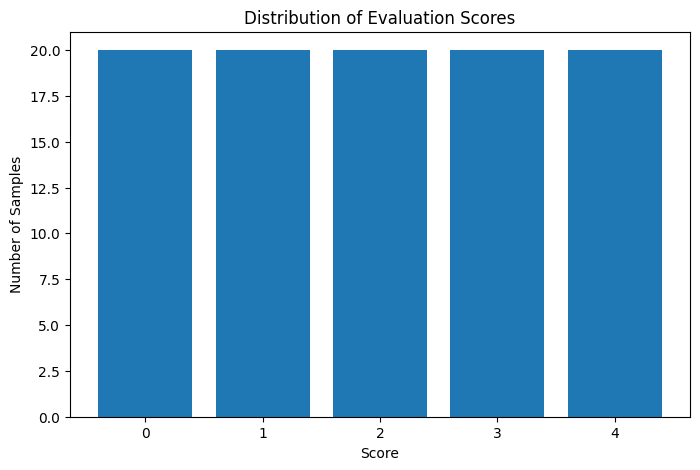

In [5]:
score_counts = df["score"].value_counts().sort_index()

score_percent = (
    score_counts / len(df) * 100
).round(2)
# round to 2 decimal places for better readability like 33.33% instead of 33.3333333333% 

score_summary = pd.DataFrame({
    "Count": score_counts,
    "Percentage (%)": score_percent
})

display(score_summary)

plt.figure(figsize=(8,5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.xlabel("Score")
plt.ylabel("Number of Samples")
plt.title("Distribution of Evaluation Scores")

plt.show()

## 6. Explore Text Length Statistics
In this section, we analyze the length of textual fields in the dataset.

Understanding text length is useful because transformer models process input as sequences of tokens, and very long inputs may increase memory usage and training time.

We will measure the approximate length of:

- Reference responses
- Submitted responses
- Rationales

This analysis helps estimate dataset complexity and supports later model configuration decisions such as sequence length selection.

In [6]:
df["reference_length"] = (
    df["reference"].apply(lambda x: len(x.split()))
)

df["submission_length"] = (
    df["submission"].apply(lambda x: len(x.split()))
)

df["rationale_length"] = (
    df["rationale"].apply(lambda x: len(x.split()))
)

length_stats = df[
    [
        "reference_length",
        "submission_length",
        "rationale_length"
    ]
].describe()

display(length_stats)

,reference_length,submission_length,rationale_length
count,100.000000,100.000000,100.000000
mean,49.700000,28.090000,22.970000
std,8.967393,18.958272,6.937608
min,32.000000,2.000000,9.000000
25%,43.750000,13.000000,18.750000
50%,49.000000,25.000000,24.000000
75%,53.000000,34.250000,27.250000
max,69.000000,87.000000,46.000000


## 7. Create Train / Validation / Test Split
we split the dataset into training, validation, and testing subsets.

The split is necessary to evaluate model performance fairly.

The subsets have different purposes:

- Training set: used to train the model.
- Validation set: used to monitor performance during fine-tuning and reduce overfitting.
- Test set: used only for final evaluation and comparison.

We will preserve score balance across all splits using stratified sampling.

In [7]:
# First split:
# Train = 80%
# Temporary = 20%

train_df, temp_df = train_test_split(df,test_size=0.2, random_state=42, stratify=df["score"])

# Second split:
# Validation = 10%
# Test = 10%

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["score"])

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 80
Validation: 10
Test: 10


## 8. Save Split Files
We need to save the files for later use.

In [ ]:
def save_jsonl(df, path):
    # if u add new samples to the dataset, this will prevent overwriting existing files and losing data.
    # if you want to overwrite, just delete the existing file before running this code.
    # or you can comment this if statement below.
    if os.path.exists(path):
        print(f"File already exists: {path} (skipping)")
        return
    with open(path, "w", encoding="utf-8") as f:
        for _, row in df.iterrows():
            json.dump(row.to_dict(), f)
            f.write("\n")

save_jsonl(train_df, "../data/train.jsonl")
save_jsonl(val_df, "../data/val.jsonl")
save_jsonl(test_df, "../data/test.jsonl")

print("Done (safe save).")

File already exists: ../data/train.jsonl (skipping)
File already exists: ../data/val.jsonl (skipping)
File already exists: ../data/test.jsonl (skipping)
Done (safe save).


## 9. Summary
In this notebook, we performed a complete exploratory data analysis (EDA) of the Customer Support Reply Evaluator dataset.

We started by loading and inspecting the dataset to ensure it follows the required structure. Each sample contains the six required fields: task, reference, submission, rubric, score, and rationale.

We then validated data integrity by checking for missing values and confirming that all score labels are within the expected range (0–4).

Next, we analyzed the score distribution and confirmed that the dataset is perfectly balanced across all classes, which is beneficial for model training.

We also examined text length statistics for reference responses, submissions, and rationales to better understand input complexity and to help determine suitable model configuration parameters.

Finally, we split the dataset into training, validation, and test sets using stratified sampling to preserve label distribution, and saved the splits for later use in model training and evaluation.

Overall, the dataset is clean, well-structured, balanced, and ready for the next phase: baseline modeling and fine-tuning using an instruction-tuned transformer model.